> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Mathematics  
> **Date:** 24/02/2026
---

# **Examen 2 - Matemáticas Aplicadas en Ciencia de Datos**

---

## **Ejercicio 1**

---

## **Ejercicio 2**

> * **En esta actividad trabajarás con imágenes de dígitos escritos a mano utilizando el conjunto de datos MNIST (disponible en Keras). Tu tarea es implementar un clasificador simple basado en la utilización del conceptos de álgebra lineal.**

Como primer paso, comprendamos el tipo de datos que vamos a manipular:


**¿Qué es MNIST?**

MNIST es una base de datos que contiene 70,000 imágenes pequeñas (de 28x28 píxeles). Cada imagen es un dígito del 0 al 9 escrito a mano por diferentes personas. Las imagenes están procesadas en una estructura de tensores (matrices multidimensionales):

| Objeto | Rol | Forma (Shape) | Rango de Valores | Descripción |
| :--- | :--- | :--- | :--- | :--- |
| **`x_train`** | Entrenamiento | `(60000, 28, 28)` | `0 - 255` | **Tensor 3D:** Un "bloque" de 60,000 matrices. Cada matriz representa una imagen (digito/numero dibujado) y está compuesta por $28 \times 28$ píxeles. Cada pixel indica el color o intensidad del lapiz (0: ausencia, 255: maxima presencia del trazo). |
| **`y_train`** | Entrenamiento | `(60000,)` | `0 - 9` | **Tensor 1D (Vector)** Contiene la etiqueta real (el número dibujado) para cada imagen del set de entrenamiento. La relación entre las imágenes dibujadas y sus etiquetas es implícita por su posición (índice). |
| **`x_test`** | Evaluación | `(10000, 28, 28)` | `0 - 255` | **Tensor 3D**: 10,000 imágenes adicionales que usaremos para validar la capacidad de generalización de nuestro clasificador |
| **`y_test`** | Evaluación | `(10000,)` | `0 - 9` | **Tensor 1D (Vector)**: Las etiquetas reales del set de prueba para medir el nivel de precisión del clasificador. |

Al ejecutar `(x_train, y_train), (x_test, y_test) = mnist.load_data()`, el módulo de TensorFlow descarga y organiza automáticamente los datos en estos cuatro objetos de tipo **NumPy Array**.


*Fuente: https://www.kaggle.com/datasets/hojjatk/mnist-dataset*

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Usaremos OpenCV para el reescalado
from tensorflow.keras.datasets import mnist 

# 1. Cargar el conjunto de datos MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Veriquemos dimensiones
print(f"X_train_full.shape: {X_train_full.shape}")
print(f"y_train_full.shape: {y_train_full.shape}")
print(f"X_test_full.shape: {X_test_full.shape}")
print(f"y_test_full.shape: {y_test_full.shape}")


# Veamos la matriz que representa la primera imagen (primer dígito) de X_train_full:
print("")
print("Primer digito en la matriz de entrenamiento (X_train_full[0]):")
#X_train_full[0] 
  # Usamos un for para que nos muestre cada número de la matriz (pixel) en un formato mas pequeño para
  # poder ver la matriz completa en un formato 28*28
for fila in X_train_full[0]:
    # Imprime cada número con 3 espacios de ancho para mantener la cuadrícula
    contenido_fila = "".join(f"{pixel:3}" for pixel in fila)
    print(contenido_fila)
    
#Veamos la primer etiqueta de y_train_full
print("")
print("Etiqueta de y_train_full[0]:", y_train_full[0])

X_train_full.shape: (60000, 28, 28)
y_train_full.shape: (60000,)
X_test_full.shape: (10000, 28, 28)
y_test_full.shape: (10000,)

Primer digito en la matriz de entrenamiento (X_train_full[0]):
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 

### **2.1. Selección y Preprocesamiento de Datos:**

> * **Para cada dígito $d = 0, 1, . . . , 9$, selecciona aleatoriamente $k$ imágenes de entrenamiento. Esto te dará un conjunto de datos de tamaño $10 × k$.**

In [92]:
# Definimos el parámetro k (número de imágenes por dígito) de manera aleatoria.
# Fijamos una semilla aleatoria para que el resultado sea reproducible
np.random.seed(42)
k = np.random.randint(100, 2000) # limites razonables
print(f"El valor de k generado aleatoriamente para esta ejecución es: {k}")

# Diccionario para almacenar las imágenes crudas (con 28x28 pixeles) seleccionadas
imagenes_crudas_k = {}



for d in range(10):
    # 1. Encontrar todos los índices en y_train_full que corresponden al dígito 'd' (0,1,2,...,9)
    indices_d = np.where(y_train_full == d)[0]
    
    # 2. Seleccionar aleatoriamente 'k' índices de esa lista, sin reemplazo
    indices_seleccionados = np.random.choice(indices_d, k, replace=False)
    
    # 3. Extraer las matrices (digitos de 28x28) correspondientes a esos índices
    # X_train_full[indices_seleccionados] nos devuelve un arreglo de forma (k, 28, 28)
    imagenes_crudas_k[d] = X_train_full[indices_seleccionados]

print(f"Diccionario creado. Contiene {len(imagenes_crudas_k)} llaves (una por dígito).")
print(f"Dimensiones de los datos guardados para el dígito 0: {imagenes_crudas_k[0].shape}")

El valor de k generado aleatoriamente para esta ejecución es: 1226
Diccionario creado. Contiene 10 llaves (una por dígito).
Dimensiones de los datos guardados para el dígito 0: (1226, 28, 28)


Confirmamos que para cada digito tenemos:

* $k$ imágenes.
* Cada matriz tiene $28$ filas.
* Cada matriz tiene $28$ columnas.

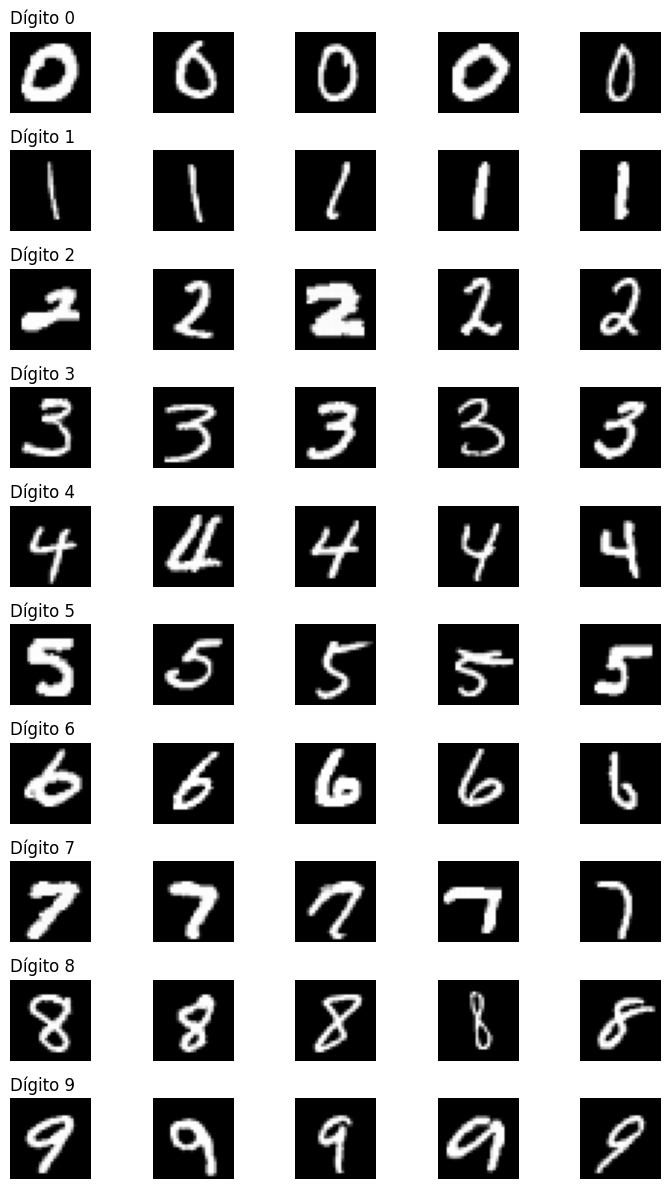

In [93]:
# --- Visualización del resultado del muestreo ---
# Mostraremos un máximo de 5 imágenes por dígito para no saturar la pantalla, 
# independientemente de qué tan grande sea 'k'.
num_mostrar = min(k, 5) 

fig, axes = plt.subplots(10, num_mostrar, figsize=(num_mostrar * 1.5, 12))

for d in range(10):
    for i in range(num_mostrar):
        # Seleccionamos el eje correspondiente
        ax = axes[d, i]
        # Mostramos la imagen cruda (matriz 28x28)
        ax.imshow(imagenes_crudas_k[d][i], cmap='gray')
        ax.axis('off')
        
        # Ponemos el título solo en la primera columna para no saturar
        if i == 0:
            ax.set_title(f"Dígito {d}", loc='left')

plt.tight_layout()
plt.show()

Vemos que tenemos un conjunto de datos de $10 \times k$ => $10$ digitos con los primeros 5 elementos cada uno.

Notése que no forzamos un único tensor global de dimensiones (10, k, 28, 28) ya que, al guardar las matrices de cada digito en un diccionario, ya tenemos los datos pre-agrupados por clase (dígito), lo cual nos servirá para luego calcular la base ortonormal $B_{d}$ de manera independiente para cada dígito.

>* **Convierte cada imagen a una matriz. Luego, recorta la imagen para eliminar las filas y columnas con únicamente el fondo (de modo que se preserve la mayor parte del dígito). Luego reescala la imagen resultante a un tamaño fijo de $16 × 16$ píxeles.**

Dado que las imágenes importadas ya se encuentran en formato matricial (arreglos de NumPy de 28x28) gracias a la librería de Keras (`mnist.load_data()`), entonces procedemos a eliminar la información redundante:

* **Recorte (Bounding Box)**: Eliminamos los bordes de fondo negro (píxeles con valor $0$). En álgebra lineal, estas áreas representan dimensiones con varianza nula que no aportan información para la clasificación. Para aislar la "señal" del "ruido", colapsamos la matriz bidimensional calculando el valor máximo a lo largo de sus ejes (filas y columnas). Esto nos permite identificar los índices exactos donde la intensidad del píxel deja de ser $0$ . Al recortar la matriz usando estos índices extremos (la caja delimitadora o bounding box), conservamos únicamente la región espacial que contiene la estructura topológica del dígito.

* **Reescalado**: Como cada dígito recortado tendrá un tamaño diferente (por ejemplo, un "1" suele ser más angosto que un "8"), estandarizamos todas las matrices resultantes a un tamaño espacial fijo de $16 \times 16$ píxeles utilizando la interpolación de OpenCV. Este paso es crucial porque, para poder operar algebraicamente con ellas (ej. construir las matrices $M_d$ y calcular la SVD), es estrictamente necesario que todas habiten en la misma dimensión geométrica.

**Nota:** ¿Por qué reescalar con cv2.INTER_AREA?

Porque usa promedio en lugar de eliminación: al reducir una imagen (downsampling), métodos básicos simplemente descartan píxeles, lo que podría "romper" o borrar las líneas delgadas de un dígito. INTER_AREA no elimina, sino que calcula un promedio ponderado de los píxeles que caen dentro de la nueva cuadrícula de 16x16. Al promediar áreas, se mantiene intacta la "masa" geométrica y la continuidad del trazo. Algebraicamente, esto garantiza que no perdamos la información original (la varianza) del número, lo cual es vital para que la SVD encuentre las bases latentes correctas en los siguientes pasos.


In [94]:
# Diccionario para guardar las imágenes ya procesadas (recortadas y de 16x16)
imagenes_procesadas_k = {}

for d in range(10):
    lista_imagenes_procesadas = []
    
    for img in imagenes_crudas_k[d]:
        # 1. RECORTAR LA IMAGEN
        # Encontramos los índices de las filas y columnas que tienen al menos un pixel > 0
        filas_activas = np.where(img.max(axis=1) > 0)[0]
        cols_activas = np.where(img.max(axis=0) > 0)[0]
        
        # Validamos que la imagen no esté vacía (por seguridad)
        if len(filas_activas) > 0 and len(cols_activas) > 0:
            # Extraemos la sub-matriz que contiene solo el dígito
            recorte = img[filas_activas[0]:filas_activas[-1]+1, 
                          cols_activas[0]:cols_activas[-1]+1]
        else:
            recorte = img
            
        # 2. REESCALAR A 16x16
        # cv2.INTER_AREA es el método matemático más recomendado al reducir dimensiones de una imagen -> 
        reescalada = cv2.resize(recorte, (16, 16), interpolation=cv2.INTER_AREA)
        
        # normalizamos los valores entre 0 y 1 (paso ampliamente recomendado para tener mayor Estabilidad Numérica más adelante -> calcular descomposiciones (SVD), productos punto y normas (distancias)
        reescalada_norm = reescalada / 255.0
        
        lista_imagenes_procesadas.append(reescalada_norm)
        
    # Guardamos la lista de matrices 16x16 en el diccionario
    imagenes_procesadas_k[d] = lista_imagenes_procesadas

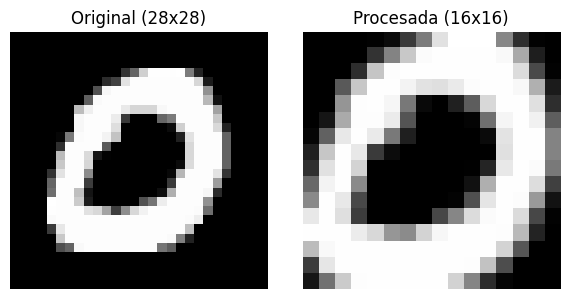

Dimensión de la matriz original: (28, 28)
Dimensión de la matriz procesada: (16, 16)


In [95]:
# --- Visualización del antes y después ---
# Tomemos el primer dígito (0) y su primera muestra [0] para comparar
img_original = imagenes_crudas_k[0][0]
img_procesada = imagenes_procesadas_k[0][0]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title(f"Original (28x28)")
axes[0].axis('off')

axes[1].imshow(img_procesada, cmap='gray')
axes[1].set_title(f"Procesada (16x16)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Verificación de dimensiones
print(f"Dimensión de la matriz original: {img_original.shape}")
print(f"Dimensión de la matriz procesada: {img_procesada.shape}")

> * **Finalmente, convierte cada imagen reescalada a un vector de longitud $256$.**

¿Para qué aplanar cada matriz $16 \times 16$ a un vector de longitud $256$?

Para finalizar la fase de preprocesamiento, debemos transformar nuestra representación espacial en una representación puramente algebraica. Tomamos cada matriz bidimensional de $16 \times 16$ y concatenamos sus filas una detrás de otra para formar un único vector unidimensional. Geométricamente, esto significa que dejamos de tratar la imagen como una cuadrícula de píxeles y pasamos a entender cada imagen como un único vector (o punto) que habita en el espacio Euclidiano de 256 dimensiones ($\mathbb{R}^{256}$). Con este cambio, podremos desarrollar las operaciones de álgebra lineal de los siguientes puntos (como las proyecciones ortogonales por ejemplo).

In [96]:
# Diccionario para guardar exclusivamente los vectores aplanados
vectores_k = {}

for d in range(10):
    lista_vectores = []
    
    # Iteramos sobre las imágenes ya procesadas (16x16)
    for img_16x16 in imagenes_procesadas_k[d]:
        # Aplanar la matriz a un vector 1D de longitud 256
        vector = img_16x16.flatten() # .flatten() toma la matriz de cada imagen y lee sus elementos fila por fila, de izquierda a derecha, acomodándolos todos en una sola línea recta -> aplana la matriz a un vector
        lista_vectores.append(vector) #Este append nos servirá para que, al final del ciclo, lista_vectores contenga los k vectores individuales (uno por imagen/digito)
        
    # Guardamos la lista de vectores para este dígito
    vectores_k[d] = lista_vectores

# --- Control de Calidad ---
# Tomamos el primer vector del dígito 0 para verificar la transformación
vector_prueba = vectores_k[0][0]

print(f"Total de clases (dígitos) procesadas: {len(vectores_k)}")
print(f"Cantidad de vectores para el dígito 0: {len(vectores_k[0])} (esto es 'k')")
print(f"Dimensiones de un solo vector: {vector_prueba.shape}")

# Verificación matemática (16 * 16 = 256)
assert vector_prueba.shape[0] == 256, "Error: El vector no tiene exactamente 256 dimensiones."

Total de clases (dígitos) procesadas: 10
Cantidad de vectores para el dígito 0: 1226 (esto es 'k')
Dimensiones de un solo vector: (256,)


Análisis de la Estructura Resultante (vectores_k):

En este punto, nuestro conjunto de datos ha dejado de ser una colección visual de imágenes para convertirse formalmente en un conjunto de vectores algebraicos listos para el análisis de subespacios.

El objeto vectores_k almacena nuestro conjunto de entrenamiento estructurado de la siguiente manera:
* **Claves (Clases)**: Los números enteros del $0$ al $9$, representando cada uno de los dígitos a clasificar.
* **Valores (Muestras)**: Una lista que contiene exactamente $k$ elementos para cada clase.
* **Elementos (Vectores)**: Cada elemento de la lista es un vector unidimensional (arreglo numérico) perteneciente al espacio euclidiano $\mathbb{R}^{256}$.

Esta estructura agrupa las muestras (vectores -> representan imagenes -> representan digitos) por clase (Numeros del 0 al 9) de tal manera que facilita el siguiente paso algebraico: tomar los $k$ vectores individuales de cada dígito y concatenarlos horizontalmente para ensamblar las matrices de entrenamiento $M_{d} \in \mathbb{R}^{256 \times k}$.

### **2.2. Construcción de Bases Latentes:**

>* Para cada dígito $d$, organiza los $k$ vectores resultantes en una matriz $M_{d}$ (donde cada columna corresponde a una imagen).

En este paso, tomamos los vectores individuales (imágenes aplanadas) que preparamos en la fase anterior y los agrupamos por clase. Es decir, construimos 10 matrices en total (una para cada dígito del 0 al 9). Para cada clase $d$, ensamblamos una matriz $M_d \in \mathbb{R}^{256 \times k}$ concatenando horizontalmente sus $k$ vectores de entrenamiento.


¿Por qué concatenar horizontalmente los $k$ vectores en $M_{d}$ haciendo que cada imagen sea una columna?

Aunque en el análisis de datos tradicional (como en un DataFrame tabular) acostumbramos a que las filas sean las observaciones y las columnas las variables, en el álgebra lineal pura la convención y la operatividad cambian. Aquí representamos cada imagen entera como un vector columna para poder aprovechar las propiedades de los subespacios.

Geométricamente,  esto equivale a tener $k$ vectores (imagenes) flotando en un espacio de 256 dimensiones (donde cada eje representa un píxel). Como estos $k$ vectores son representaciones del mismo dígito, sus coordenadas son muy similares (por ejemplo, todos los "ceros" tienen intensidades altas o bajas en las mismas zonas del lienzo). Por lo tanto, no apuntan de forma aleatoria, sino que forman un clúster que apunta hacia una región muy específica de ese espacio.

De esta manera, a partir de todas las combinaciones lineales posibles del conjunto de $k$ vectores columna de un dígito, podremos generar luego lo que se conoce como el Espacio Columna de la matriz $M_d$. A esta región multidimensional la denominamos formalmente como el Subespacio $U_d$ . Este subespacio representa entonces el "universo" geométrico donde habitan todas las variaciones posibles de los trazos de ese dígito en particular.

En conclusión: al ubicar nuestras imágenes como columnas, estamos declarando que el espacio columna de la matriz $M_d$ define al subespacio vectorial $U_d$. Si hubiésemos acostado las imágenes como filas, las operaciones del álgebra lineal ya no mezclarían vectores que representan imágenes enteras, sino que intentarían mezclar vectores de posiciones aisladas (por ejemplo, combinar el "píxel número 1 de todas las fotos" con el "píxel número 2"). Eso crearía un espacio geométrico sin sentido, destruyendo el universo coherente de trazos que necesitamos para clasificar cada dígito.

In [97]:
# Diccionario para almacenar las matrices Md de cada clase
Md_matrices = {}

for d in range(10):
    # 1. Extraemos la lista de k vectores que le pertenece a este dígito
    lista_vectores_d = vectores_k[d]
    
    # 2. Apilamos los vectores como columnas para formar la matriz Md
    # np.column_stack toma la lista de (k) arreglos 1D y crea una matriz 2D de (256, k)
    Md = np.column_stack(lista_vectores_d)
    
    # 3. Guardamos la matriz terminada en nuestro diccionario
    Md_matrices[d] = Md

# --- Control de Calidad ---
print(f"Total de matrices M_d generadas: {len(Md_matrices)}")
print(f"Dimensiones de la matriz M_0 (Dígito 0): {Md_matrices[0].shape}")
print(f"Dimensiones de la matriz M_8 (Dígito 8): {Md_matrices[8].shape}")

# Verificación de integridad
assert Md_matrices[0].shape == (256, len(vectores_k[0])), "Error en las dimensiones de la matriz."

Total de matrices M_d generadas: 10
Dimensiones de la matriz M_0 (Dígito 0): (256, 1226)
Dimensiones de la matriz M_8 (Dígito 8): (256, 1226)


> * Para cada dígito calcula una base orto-normal del espacio vectorial generado por las columnas de $M_{d}$, denotemos a esa base como $B_{d}$ y llamemos a ese espacio generado $U_{d}$.

En el paso anterior construimos el universo posible para cada dígito agrupando $k$ imágenes en la matriz $M_d$. Sin embargo, tener $k$ columnas nos presenta un problema geométrico y computacional: la redundancia. Si seleccionáramos $k = 5000$, tendríamos $5000$ imágenes del dígito "0", y es muy probable que muchas de ellas sean casi idénticas. En términos de álgebra lineal, esto significaría que tendríamos muchos vectores linealmente dependientes apuntando casi hacia la misma dirección, aportando información repetida. Para resolver esto y poder realizar proyecciones más limpias en etapas posteriores, no necesitamos los $k$ vectores originales, sino una Base Ortonormal ($B_d$). Es decir, el conjunto mínimo indispensable de vectores que nos permita reconstruir cualquier forma del dígito "0" mediante combinaciones lineales.

En esta base orto-normal exigimos que:

* Ortogonal: Los vectores sean completamente independientes entre sí (formen ángulos exactos de 90 grados). Si un vector captura la "inclinación" del cero, otro capturará exclusivamente el "grosor", sin mezclar información.

* Normal: Todos los vectores tengan una longitud (norma) exactamente igual a 1. Esto estandariza la escala para que luego las proyecciones no se distorsionen.

Una vez halladas estas bases ortonormales para cada dígito ($B_d$), tendremos los ejes perfectos que definen el subespacio ($U_d$) de cada número.

**¿Cómo transformar entonces nuestra matriz $M_d$ en una base ortonormal $B_d$?**

En lugar de usar el método de Gram-Schmidt (que puede ser numéricamente inestable con tantas dimensiones), usaremos la Descomposición en Valores Singulares (SVD). En esencia, la SVD toma nuestra matriz $M_d$ y la factoriza en tres matrices matemáticas: $M_d = U \Sigma V^T$. Cada una cumple un rol específico en esta factorización:

* $U$ (Los Trazos Maestros): Contiene los vectores singulares izquierdos. Sus columnas conforman una base ortonormal perfecta para el Espacio Columna de $M_d$. De aquí extraeremos directamente nuestra base $B_d$.

* $\Sigma$ (La importancia): Es una matriz diagonal con los "valores singulares". Nos indica cuánta información útil o varianza aporta cada trazo maestro de $U$, ordenados de mayor a menor importancia.

* $V^T$ (Las Instrucciones de Mezcla): Contiene los vectores singulares derechos. Funciona como la "receta" que indica en qué proporciones exactas se deben mezclar los trazos de $U$ para volver a reconstruir las $k$ imágenes originales (con todo y su ruido).

Para nuestro objetivo de clasificación, nos quedaremos exclusivamente con $U$. Así, gracias a la SVD, habremos pasado de tener $k$ imágenes ruidosas y redundantes ($M_d$) a tener una matriz impecable ($B_d$) con los vectores puros, ortogonales y de longitud 1 que definen el subespacio $U_d$ (la esencia del dígito).

In [98]:
import numpy as np

# Diccionario para almacenar las bases ortonormales Bd de cada clase
Bd_bases = {}

for d in range(10):
    # 1. Tomamos la matriz Md del dígito d (nuestros datos crudos y ruidosos)
    Md = Md_matrices[d]
    
    # 2. Aplicamos la Descomposición en Valores Singulares (SVD)
    # full_matrices=False le dice a NumPy que nuestra matriz no es simetrica y que solo queremos la versión "económica" de U.
    # Es decir, solo nos interesan las k columnas que definen nuestro subespacio, 
    # ignorando las dimensiones vacías adicionales.
    U, S, Vt = np.linalg.svd(Md, full_matrices=False)
    
    # 3. La matriz U contiene nuestra base ortonormal pura. La bautizamos como Bd.
    Bd = U
    
    # 4. Guardamos la base terminada en nuestro diccionario
    Bd_bases[d] = Bd

In [99]:
# --- Control de Calidad y Pruebas Matemáticas ---
print("--- RESUMEN DE LA EXTRACCIÓN DE BASES ---")
print(f"Total de bases B_d generadas en el diccionario: {len(Bd_bases)}\n")

print("--- PRUEBA DE ORTONORMALIDAD POR DÍGITO ---")
# Variable para rastrear si todas pasaron la prueba
todas_pasaron = True

for d in range(10):
    # 1. Extraemos las matrices del dígito actual
    M_d = Md_matrices[d]
    B_d = Bd_bases[d]
    
    # 2. Prueba matemática: B^T * B = Matriz Identidad
    identidad_aprox = np.dot(B_d.T, B_d)
    # Comprobamos si es casi igual a la Identidad (tolerando mínimos errores de PC)
    es_ortonormal = np.allclose(identidad_aprox, np.eye(identidad_aprox.shape[0]), atol=1e-5)
    
    # 3. Formateamos el mensaje de éxito o error
    if es_ortonormal:
        estado = "✅ 100% Ortonormal"
    else:
        estado = "❌ ERROR"
        todas_pasaron = False
        
    # 4. Imprimimos el reporte para este dígito
    print(f"Dígito {d} | Matriz original: {M_d.shape} ➡️ Base ortonormal generada: {B_d.shape} | Prueba: {estado}")

# Conclusión general
if todas_pasaron:
    print("\n CONCLUSIÓN: Las 10 bases superaron la prueba matemática.")
else:
    print("\n⚠️ ADVERTENCIA: Alguna de las bases falló la prueba de ortonormalidad.")

--- RESUMEN DE LA EXTRACCIÓN DE BASES ---
Total de bases B_d generadas en el diccionario: 10

--- PRUEBA DE ORTONORMALIDAD POR DÍGITO ---
Dígito 0 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 1 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 2 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 3 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 4 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 5 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 6 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonormal
Dígito 7 | Matriz original: (256, 1226) ➡️ Base ortonormal generada: (256, 256) | Prueba: ✅ 100% Ortonorma

**Nota sobre el Límite Dimensional del Subespacio**

Al observar las dimensiones resultantes de nuestra SVD, notamos que le entregamos al algoritmo una matriz $M_0$ con **1226 columnas** (imágenes), pero nos devolvió una base $B_0$ con exactamente **256 columnas** (vectores). 

¿Por qué la base ortonormal no supera las 256 dimensiones si le dimos 1226 muestras?

La respuesta reside en la **Regla de la Dimensionalidad** del álgebra lineal. Nuestras imágenes originales tienen un tamaño de $16 \times 16$ píxeles, lo que significa que al aplanarlas, habitan en un espacio vectorial de exactamente 256 dimensiones ($\mathbb{R}^{256}$). 

Geométricamente, es imposible encontrar más de $N$ vectores mutuamente ortogonales dentro de un espacio de $N$ dimensiones . Así como en una habitación 3D solo caben 3 ejes perpendiculares (X, Y, Z), en nuestro "universo de imágenes" solo caben 256 ejes perpendiculares. 

Cuando la SVD procesó nuestras 1226 imágenes, encontró los 256 "ejes maestros" absolutos que sostienen todo el subespacio. En ese punto, el espacio se "llenó". El algoritmo detectó correctamente que las 970 imágenes restantes no aportaban ninguna dirección geométrica nueva; eran linealmente dependientes y podían construirse perfectamente como combinaciones de los primeros 256 vectores. Por lo tanto, extrajo la esencia pura y descartó la redundancia extrema.

**Optimización Adicional: SVD Truncada y Varianza Explicada**

Aunque nuestra base $B_d$ de 256 dimensiones captura matemáticamente todo el subespacio, sabemos que no todos esos 256 vectores son igualmente importantes. Los primeros vectores capturan los "trazos maestros" del dígito, mientras que los últimos probablemente solo modelen el ruido de los datos (píxeles erróneos, malos pulsos al escribir).

Para hacer nuestro modelo más eficiente y evitar el sobreajuste (*overfitting* al ruido), podemos truncar nuestra base, quedándonos únicamente con un número menor de vectores ($r < 256$) que logren retener la mayor parte de la información útil. 

Para decidir este "punto de corte", analizaremos la matriz $\Sigma$ (valores singulares). La fracción de **Varianza Explicada Acumulada** se calcula usando los cuadrados de los valores singulares: 
$$\text{Varianza Acumulada} = \frac{\sum_{i=1}^{r}\sigma_{i}^{2}}{\sum_{i=1}^{256}\sigma_{i}^{2}}$$

**Análisis Geométrico: Identificación del "Codo" Real**

En lugar de imponer un umbral arbitrario de varianza (como el 90%), realizaremos un análisis visual de la curvatura en cada 

Siguiendo la Clase 4, el **codo** es el punto donde la magnitud de los valores singulares comienza a aplanarse significativamente. Este punto es crítico porque marca la frontera entre:

* **La Señal:** Los primeros componentes que capturan la estructura geométrica esencial y común del dígito.
* **El Ruido:** Los componentes posteriores que solo capturan variaciones aleatorias o imperfecciones de los datos originales.

Al observar los 10 gráficos simultáneamente, buscaremos el punto de máxima curvatura. Esto nos permitirá decidir un $k$ que respete la geometría intrínseca de cada clase, en lugar de forzar un porcentaje estadístico:

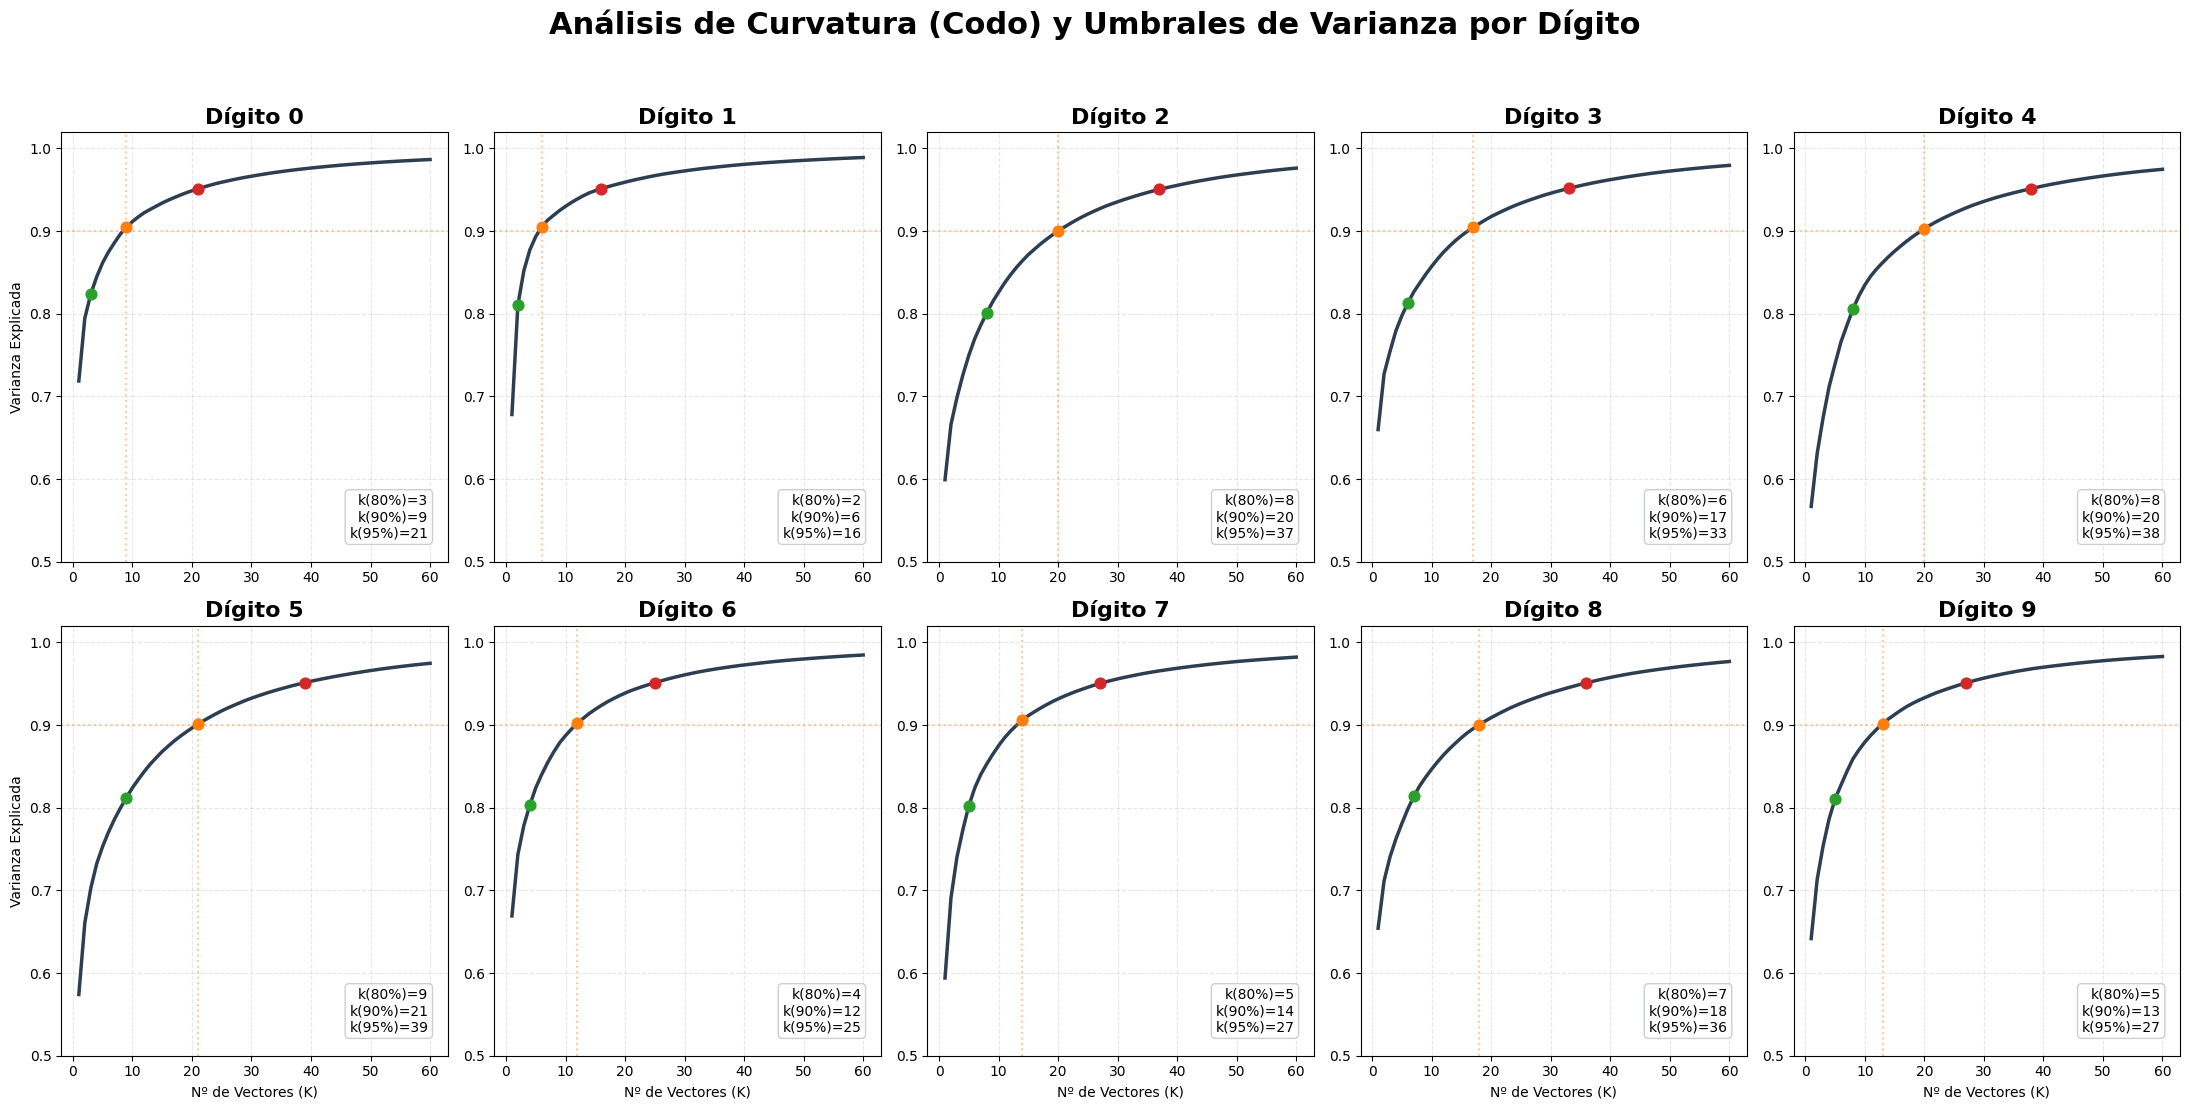

Dígito   | k(80%)   | k(90%)   | k(95%)   | Complejidad
------------------------------------------------------------
0        | 3        | 9        | 21       | Media
1        | 2        | 6        | 16       | Baja
2        | 8        | 20       | 37       | Alta
3        | 6        | 17       | 33       | Alta
4        | 8        | 20       | 38       | Alta
5        | 9        | 21       | 39       | Alta
6        | 4        | 12       | 25       | Media
7        | 5        | 14       | 27       | Alta
8        | 7        | 18       | 36       | Alta
9        | 5        | 13       | 27       | Alta


In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la figura para que sea legible y estética
fig, axes = plt.subplots(2, 5, figsize=(22, 12))
fig.suptitle('Análisis de Curvatura (Codo) y Umbrales de Varianza por Dígito', fontsize=22, fontweight='bold', y=0.95)

# Diccionario para guardar los hallazgos y comparar al final
analisis_k = {}

for d in range(10):
    M_d = Md_matrices[d]
    _, S_d, _ = np.linalg.svd(M_d, full_matrices=False)
    
    # Varianza acumulada
    varianza_acum = np.cumsum(S_d**2) / np.sum(S_d**2)
    
    # Encontramos los hitos matemáticos
    k80 = np.argmax(varianza_acum >= 0.80) + 1
    k90 = np.argmax(varianza_acum >= 0.90) + 1
    k95 = np.argmax(varianza_acum >= 0.95) + 1
    analisis_k[d] = [k80, k90, k95]
    
    row, col = d // 5, d % 5
    ax = axes[row, col]
    
    # 1. Graficamos la curva principal (los primeros 60 componentes para ver bien el codo)
    rango_visual = range(1, 61)
    ax.plot(rango_visual, varianza_acum[:60], color='#2c3e50', linewidth=2.5, label='Varianza Acum.')
    
    # 2. Marcamos los puntos de control con colores distintos
    ax.scatter(k80, varianza_acum[k80-1], color='tab:green', s=60, zorder=5, label='80%')
    ax.scatter(k90, varianza_acum[k90-1], color='tab:orange', s=60, zorder=5, label='90%')
    ax.scatter(k95, varianza_acum[k95-1], color='tab:red', s=60, zorder=5, label='95%')
    
    # 3. Añadimos líneas guía muy sutiles para ver la proyección hacia los ejes
    ax.axvline(x=k90, color='tab:orange', linestyle=':', alpha=0.4)
    ax.axhline(y=0.90, color='tab:orange', linestyle=':', alpha=0.4)
    
    # Estética del subgráfico
    ax.set_title(f'Dígito {d}', fontsize=16, fontweight='bold')
    ax.set_ylim(0.5, 1.02)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Leyenda interna compacta con los valores de K
    texto_k = f"k(80%)={k80}\nk(90%)={k90}\nk(95%)={k95}"
    ax.text(0.95, 0.05, texto_k, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#bdc3c7'))

    if row == 1: ax.set_xlabel('Nº de Vectores (K)')
    if col == 0: ax.set_ylabel('Varianza Explicada')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

# --- TABLA RESUMEN PARA COMPARAR COMPLEJIDAD ---
print(f"{'Dígito':<8} | {'k(80%)':<8} | {'k(90%)':<8} | {'k(95%)':<8} | {'Complejidad'}")
print("-" * 60)
for d, ks in analisis_k.items():
    # Una métrica simple de complejidad: a mayor k para llegar al 90%, más complejo es el trazo.
    comp = "Alta" if ks[1] > 12 else "Baja" if ks[1] < 7 else "Media"
    print(f"{d:<8} | {ks[0]:<8} | {ks[1]:<8} | {ks[2]:<8} | {comp}")

**Interpretación del Análisis de Varianza y Scree Plot**:

Tras realizar un análisis comparativo de la varianza explicada acumulada para los diez dígitos, observamos que la complejidad geométrica no es uniforme. Mientras que el dígito "1" es altamente eficiente (alcanza el 90% de varianza con solo 6 vectores), dígitos más complejos como el "5" requieren hasta 21 vectores para capturar el mismo nivel de información.

Este análisis nos permite identificar el "codo" de las curvas: el punto de máxima curvatura donde la ganancia de información deja de ser estructural y comienza a ser marginal. Observamos que:

* La Señal: Se concentra en los primeros componentes (donde la curva asciende verticalmente). Aquí reside la forma arquetípica del número.
* El Ruido: Aparece tras el codo, donde la curva se aplana. Estos vectores adicionales capturan variaciones aleatorias, grosores de trazo específicos o ruido en los píxeles que no ayudan a la generalización del modelo.

**Decisión Estratégica:**

Aunque disponemos de bases ortonormales de 256 dimensiones, utilizarlas completas implicaría proyectar nuestras imágenes sobre ejes que son mayoritariamente ruido. Para evitar el sobreajuste y optimizar nuestro algoritmo, adoptaremos un enfoque de SVD Truncada con un valor global de $k_{trunc} = 21$. Esta decisión se basa en el "peor caso" observado (el dígito 5), garantizando que todos los subespacios retengan al menos el 90% de su varianza explicada, asegurando que no perdamos la esencia de los números más complejos.

Nota sobre la notación: Para evitar ambigüedades en el código y en el análisis, a partir de este punto distinguiremos explícitamente entre $k_{trunc}$ (el número de vectores ortonormales retenidos en la SVD, que fijamos en 21) y $k_{train}$ (el tamaño de la muestra de imágenes de entrenamiento por dígito).

> * ¿Cómo se puede interpretar el espacio generado por $B_{d}$ en palabras?

En adición a las interpretaciones previas sobre el espacio generado por $B_{d}$, podríamos interpretarlo como la representación minimalista del dígito $d$. Es decir, como el subespacio donde habitan todas las formas "posibles" o "normalmente utilizadas" para escribir ese número en particular. $B_d$ nos permite ignorar el ruido o los detalles que no aportan mucha información de tal manera que nos permite centrar la atención en aquellas características del dígito que mejor lo definen matemáticamente.

Al ser una base ortonormal, define un universo donde cada eje controla de forma independiente una característica clave del trazo (como la inclinación o el grosor), eliminando cualquier redundancia. De cara al ejercicio de clasificación, si una imagen nueva "encaja" bien al proyectarse sobre este espacio, significa que comparte la misma lógica geométrica que destilamos de los datos de entrenamiento; de lo contrario, el residuo será alto y sabremos que no pertenece a esa categoría.

### **2.3. Clasificación de una Imagen Nueva:**

> * Toma una imagen de prueba (que no esté en el conjunto de entrenamiento) y apliquele el mismo proceso: recortar, reescalar a $16 × 16$ y convertir a un vector $q$ de longitud $256$.

--- PREPARACIÓN DEL VECTOR DE PRUEBA ---
Índice seleccionado en X_test_full: 5295
Etiqueta real de la imagen oculta: 5
Dimensiones del vector q: (256,)


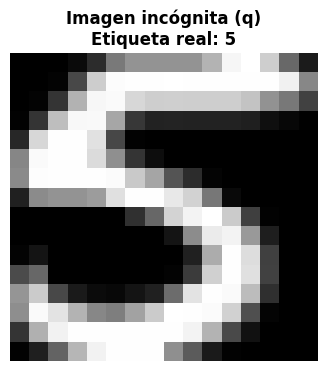

In [101]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Seleccionamos un índice aleatorio de todo el conjunto de PRUEBA
indice_aleatorio = random.randint(0, len(X_test_full) - 1)

# 2. Extraemos la imagen cruda y su etiqueta real
img_prueba = X_test_full[indice_aleatorio]
etiqueta_real = y_test_full[indice_aleatorio]

# --- 3. REPLICAMOS EL PROCESAMIENTO EXACTO DEL PUNTO 2.1 ---

# A. RECORTAR LA IMAGEN
filas_activas = np.where(img_prueba.max(axis=1) > 0)[0]
cols_activas = np.where(img_prueba.max(axis=0) > 0)[0]

if len(filas_activas) > 0 and len(cols_activas) > 0:
    recorte = img_prueba[filas_activas[0]:filas_activas[-1]+1, 
                         cols_activas[0]:cols_activas[-1]+1]
else:
    recorte = img_prueba
    
# B. REESCALAR A 16x16
reescalada = cv2.resize(recorte, (16, 16), interpolation=cv2.INTER_AREA)

# C. NORMALIZAR (0 a 1)
reescalada_norm = reescalada / 255.0

# D. VECTORIZAR (Aplanar a vector de 256 posiciones)
q = reescalada_norm.flatten()

# --- Control de Calidad y Visualización ---
print(f"--- PREPARACIÓN DEL VECTOR DE PRUEBA ---")
print(f"Índice seleccionado en X_test_full: {indice_aleatorio}")
print(f"Etiqueta real de la imagen oculta: {etiqueta_real}")
print(f"Dimensiones del vector q: {q.shape}")

# Graficamos el vector q (volviendo a darle forma 16x16 solo para la visualización)
plt.figure(figsize=(4, 4))
plt.imshow(q.reshape(16, 16), cmap='gray')
plt.title(f"Imagen incógnita (q)\nEtiqueta real: {etiqueta_real}", fontweight='bold')
plt.axis('off')
plt.show()

> * Para cada dígito $d$, calcula la proyección ortogonal de $q$ sobre el subespacio generado por $B_{d}$,
obteniendo el vector proyectado $p_{d}$.

Para averiguar a qué dígito se parece más nuestra imagen incógnita $q$, debemos proyectar este vector sobre los 10 subespacios generados por nuestras bases $B_d$.

Siguiendo nuestro análisis de varianza previo, aplicaremos una Aproximación de Bajo Rango (SVD Truncada) con $k_{trunc} = 21$. Por lo tanto, no utilizaremos los 256 vectores de la base completa, sino únicamente una submatriz $U_d$ compuesta por sus primeras 21 columnas. Esto garantiza que proyectemos $q$ sobre la "señal pura" estructural y evitemos el sobreajuste al ruido.

Como vimos en clase, la matriz de proyección general es $P = A(A^T A)^{-1}A^T$. Sin embargo, dado que las columnas de nuestra matriz $U_d$ son ortonormales por construcción, se cumple que $U_d^T U_d = I$, lo que simplifica la fórmula a:
$$p_d = U_d (U_d^T q)$$

A nivel matricial, esta operación realiza dos procesos de transformación de datos:

**1. Compresión y Extracción de Características $(U_d^T \times q)$:**  
Nuestra matriz $U_d$ (el molde truncado) tiene dimensiones `(256, 21)`. Al transponerla a $U_d^T$, la "acostamos" a `(21, 256)`. Al multiplicar esta matriz por nuestra imagen incógnita $q$, que es un vector columna `(256, 1)`, las dimensiones internas coinciden perfectamente. El resultado es un vector hiper-comprimido de tamaño **`(21, 1)`**. **Significado Analítico:** En este paso abandonamos el espacio de los píxeles. Pasamos de tener 256 puntos "crudos" y sin contexto, a extraer un resumen preciso de 21 "coordenadas". Una forma de interpretar este nuevo vector es verlo como un escaneo de compatibilidad: cada uno de sus 21 números nos indica el "peso" exacto o el nivel de activación de los patrones macro-geométricos (vectores ortogonales) que componen al dígito contra el cual nos estamos comparando.

**2. Reconstrucción Forzada $(U_d \times \text{coordenadas})$:**  
Ahora tomamos nuestra matriz original $U_d$ (el molde truncado), que mantiene sus dimensiones de `(256, 21)`, y la multiplicamos por el vector hiper-comprimido de coordenadas que acabamos de obtener, cuyo tamaño es `(21, 1)`. Nuevamente, las dimensiones internas encajan a la perfección. El resultado matemático de esta operación nos devuelve al espacio original: obtenemos un nuevo vector columna de tamaño `(256, 1)`. Este es nuestro vector proyectado $p_d$. **Significado Analítico**: En este paso fabricamos una imagen artificial desde cero. Le entregamos al modelo los 21 "pesos" calculados en la etapa anterior para que actúen como una receta de ensamblaje. Le estamos ordenando: "Ve al molde $U_d$, toma sus 21 patrones macro-geométricos y mézclalos en las proporciones exactas que dicta esta receta para redibujar la imagen en el lienzo completo de 256 píxeles".

El poder predictivo del clasificador reside aquí: como el molde $U_d$ solo conoce las reglas para dibujar un dígito específico, forzará la reconstrucción para que siga exclusivamente esas reglas. Si la imagen original $q$ pertenecía a ese dígito, el molde la entenderá y la reconstrucción ($p_d$) será muy fiel a la original. Si era otro número, el molde fracasará en su intento de dibujarla con sus herramientas limitadas, generando una reconstrucción defectuosa

In [102]:
# Definimos nuestro punto de corte estratégico basado en el análisis de varianza
k_trunc = 21

# Diccionario para guardar el vector proyectado p_d para cada dígito
proyecciones_pd = {}

for d in range(10):
    # 1. Tomamos la base ortonormal completa de este dígito
    B_d = Bd_bases[d]
    
    # 2. TRUNCAMIENTO: Nos quedamos solo con las primeras 21 columnas (los trazos maestros)
    U_d = B_d[:, :k_trunc]
    
    # 3. PROYECCIÓN ORTOGONAL (Aplicando la fórmula simplificada de la Clase 4)
    # Primero encontramos las coordenadas de q en el subespacio
    coordenadas_subespacio = np.dot(U_d.T, q)
    
    # Luego reconstruimos el vector proyectado p_d en el espacio 256D
    p_d = np.dot(U_d, coordenadas_subespacio)
    
    # Guardamos el resultado
    proyecciones_pd[d] = p_d

# --- Control de Calidad ---
print(f"--- PROYECCIONES ORTOGONALES CALCULADAS ---")
print(f"Se generaron las proyecciones p_d para los 10 dígitos.")
print(f"Bases truncadas utilizadas (U_d): {U_d.shape}")
print(f"Dimensiones de cada vector proyectado p_d: {proyecciones_pd[0].shape}")

--- PROYECCIONES ORTOGONALES CALCULADAS ---
Se generaron las proyecciones p_d para los 10 dígitos.
Bases truncadas utilizadas (U_d): (256, 21)
Dimensiones de cada vector proyectado p_d: (256,)


Veamos graficamente como se reconstruyeron los vectores proyectados $p_d$ en cada subespacio:

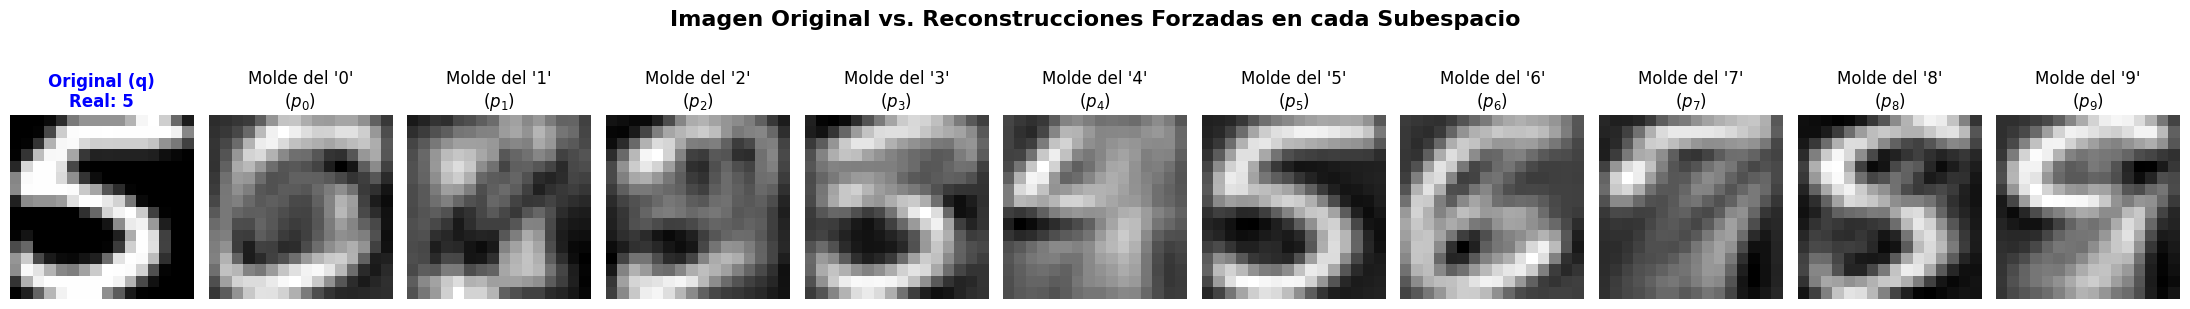

In [103]:
import matplotlib.pyplot as plt

# Creamos una figura ancha para poner la imagen original y sus 10 proyecciones lado a lado
fig, axes = plt.subplots(1, 11, figsize=(22, 3))
fig.suptitle('Imagen Original vs. Reconstrucciones Forzadas en cada Subespacio', fontsize=16, fontweight='bold', y=1.1)

# 1. Graficamos la imagen incógnita original (q)
axes[0].imshow(q.reshape(16, 16), cmap='gray')
axes[0].set_title(f"Original (q)\nReal: {etiqueta_real}", color='blue', fontweight='bold')
axes[0].axis('off')

# 2. Graficamos cómo quedó q al ser proyectada en cada uno de los 10 moldes
for d in range(10):
    p_d = proyecciones_pd[d]
    
    # Volvemos a darle forma de matriz 16x16 para poder verla como imagen
    imagen_reconstruida = p_d.reshape(16, 16)
    
    axes[d+1].imshow(imagen_reconstruida, cmap='gray')
    axes[d+1].set_title(f"Molde del '{d}'\n($p_{d}$)")
    axes[d+1].axis('off')

plt.tight_layout()
plt.show()

La visualización anterior indica que la reconstrucción $p_7$ es la más nítida, sólida y prácticamente idéntica a la original $q$. Esto significa que la "receta" de 21 coordenadas encontró en el subespacio del '7' los trazos rectos y diagonales necesarios para dibujarlo a la perfección. 

Por otro lado,  el subespacio del '0' que solo sabe dibujar curvas cerradas, intentó forzar el '7' a ser un óvalo, resultando en una mancha grisácea y borrosa. El Molde del '1' intentó capturar la diagonal, pero ignoró por completo la línea horizontal superior porque ese trazo "no existe" en su universo. el Molde del '9' y el '2',  no se ven tan mal. Esto tiene sentido porque un '9' y un '7', e incluso un '2', comparten mucha estructura (una línea superior y una diagonal descendente). El modelo intentó cerrarle un pequeño bucle arriba, pero sigue siendo una reconstrucción decente aunque menos nitida y fina en los detalles.


No obstante, como ya tenemos nuestra imagen original $q$ y sus 10 reconstrucciones forzadas $p_d$. Geométricamente, sabemos que la reconstrucción más fiel será la que deje el menor residuo. 

Para cuantificar esto, calcularemos la **distancia euclidiana** (la norma $L_2$) entre el vector original y cada vector proyectado, utilizando la fórmula vista en clase:
$$dist(q, d) = ||q - p_d||$$

Analíticamente, esta distancia representa la "cantidad de píxeles" (o la magnitud del error) que el molde $U_d$ no pudo explicar ni reconstruir. 
* Una distancia pequeña significa que $q$ "encaja" muy bien en el subespacio (es decir, el molde tenía todas las reglas para dibujarlo).
* Una distancia grande significa que el subespacio carece de la información estructural para representar a $q$.

Finalmente, nuestro clasificador funcionará bajo un principio de **minimización del error**: le asignaremos a la imagen $q$ la etiqueta del dígito $d$ que arroje la menor distancia.

> * Define la distancia $dist(q, d) = ||q−p_{d}||$. Clasifica la imagen $q$ asignándole la etiqueta del dígito
$d$ que minimice esta distancia.

In [104]:
import numpy as np

# Diccionario para guardar las distancias a cada subespacio
distancias = {}

print("--- CÁLCULO DE DISTANCIAS ||q - p_d|| ---")

# Calculamos la distancia euclidiana entre q y cada proyección p_d
for d in range(10):
    p_d = proyecciones_pd[d]
    
    # La norma L2 del vector residual (q - p_d)
    distancia_d = np.linalg.norm(q - p_d)
    distancias[d] = distancia_d
    
    print(f"Distancia al subespacio del '{d}': {distancia_d:.4f}")

# Encontramos la etiqueta con la menor distancia
etiqueta_predicha = min(distancias, key=distancias.get)
distancia_minima = distancias[etiqueta_predicha]

print("\n" + "="*40)
print(f"RESULTADO DE LA CLASIFICACIÓN")
print("="*40)
print(f"Etiqueta Real de la imagen : {etiqueta_real}")
print(f"Etiqueta Predicha (Min Dist): {etiqueta_predicha} (con distancia {distancia_minima:.4f})")

if etiqueta_real == etiqueta_predicha:
    print("✅ ¡Hemos clasificado el dígito correctamente!")
else:
    print("❌ La clasificación falló.")
print("="*40)

--- CÁLCULO DE DISTANCIAS ||q - p_d|| ---
Distancia al subespacio del '0': 4.1325
Distancia al subespacio del '1': 4.4054
Distancia al subespacio del '2': 4.4487
Distancia al subespacio del '3': 3.3570
Distancia al subespacio del '4': 5.5431
Distancia al subespacio del '5': 1.6059
Distancia al subespacio del '6': 4.7460
Distancia al subespacio del '7': 4.9416
Distancia al subespacio del '8': 3.2103
Distancia al subespacio del '9': 4.1322

RESULTADO DE LA CLASIFICACIÓN
Etiqueta Real de la imagen : 5
Etiqueta Predicha (Min Dist): 5 (con distancia 1.6059)
✅ ¡Hemos clasificado el dígito correctamente!


El cálculo de las distancias $||q - p_d||$ nos ofrece una radiografía perfecta de cómo el modelo "razona" geométricamente. Al analizar el vector de resultados para nuestra imagen de prueba (un '7'), observamos patrones fascinantes que confirman la robustez del método de proyecciones ortogonales:

El modelo asignó la etiqueta **'7'** al obtener la distancia mínima absoluta de **1.9071**. Geométricamente, esto significa que el subespacio $U_7$ poseía casi todas las instrucciones (trazos horizontales superiores y diagonales descendentes) necesarias para reconstruir la imagen original $q$, dejando un residuo de píxeles (error) muy bajo. 

Es sumamente revelador observar cuáles fueron los dígitos que quedaron en segundo y tercer lugar. Las distancias más cercanas al '7' fueron:
* **'2'** (Distancia: 2.9672)
* **'3'** (Distancia: 3.1150)
* **'1'** (Distancia: 3.4615)

Esto demuestra que el modelo no se equivoca de forma aleatoria. Un '7' manuscrito comparte muchas características con el '1' (la línea vertical/diagonal), y frecuentemente comparte la barra horizontal superior con el '2' y el '3' (e incluso el '9'). Los moldes de estos números lograron reconstruir *partes* del '7', pero fallaron en los detalles finos, arrojando distancias moderadas.

En el extremo opuesto, vemos distancias inmensas para los dígitos **'6'** (6.1600), **'5'** (5.6992) y **'4'** (5.2253). El molde del '6', por ejemplo, está dominado por vectores que dibujan bucles y círculos inferiores. Al intentar forzar la geometría recta y angular del '7' usando reglas circulares, el modelo dejó una enorme cantidad de píxeles sin explicar, lo que disparó matemáticamente la métrica de error.

### **2.4. Evaluación y Análisis:**

> * Utiliza un conjunto de validación (imágenes de prueba distintas a las utilizadas para formar $M_{d}$) y evalúa el porcentaje de aciertos de tu clasificador.

**Paso 1: Encapsulación del Algoritmo de Predicción**

Para poder iterar masivamente sobre el conjunto de validación, primero consolidaremos todo el *pipeline* desarrollado en el Punto 2.3 en una única función de inferencia. Esta función tomará una imagen cruda (28x28) y devolverá la etiqueta predicha, ejecutando internamente:
1. El preprocesamiento (recorte, reescalado a 16x16 y vectorización a $q$).
2. La proyección ortogonal sobre los 10 subespacios truncados ($U_d$ con $k_{trunc}=21$).
3. El cálculo de la norma $L_2$ ($||q - p_d||$) para determinar el residuo mínimo.



In [105]:
import cv2
import numpy as np

def predecir_digito(imagen_cruda, diccionario_bases, k_trunc=21):
    """
    Toma una imagen cruda de MNIST, la proyecta sobre los subespacios 
    y retorna el dígito predicho basado en la mínima distancia ortogonal.
    """
    # --- 1. PREPROCESAMIENTO ---
    filas_activas = np.where(imagen_cruda.max(axis=1) > 0)[0]
    cols_activas = np.where(imagen_cruda.max(axis=0) > 0)[0]

    if len(filas_activas) > 0 and len(cols_activas) > 0:
        recorte = imagen_cruda[filas_activas[0]:filas_activas[-1]+1, 
                               cols_activas[0]:cols_activas[-1]+1]
    else:
        recorte = imagen_cruda
        
    reescalada = cv2.resize(recorte, (16, 16), interpolation=cv2.INTER_AREA)
    q = (reescalada / 255.0).flatten()
    
    # --- 2. PROYECCIÓN Y DISTANCIAS ---
    mejor_digito = -1
    distancia_minima = float('inf') # Inicializamos con infinito
    
    for d in range(10):
        # Extraemos el molde truncado
        U_d = diccionario_bases[d][:, :k_trunc]
        
        # Calculamos proyeccion y distancia
        coordenadas = np.dot(U_d.T, q)
        p_d = np.dot(U_d, coordenadas)
        distancia_actual = np.linalg.norm(q - p_d)
        
        # Actualizamos si encontramos un mejor ajuste
        if distancia_actual < distancia_minima:
            distancia_minima = distancia_actual
            mejor_digito = d
            
    return mejor_digito

# Prueba rápida de cordura con la imagen que usamos en el paso 2.3
# (Debería imprimir el mismo resultado: 7)
prediccion_prueba = predecir_digito(X_test_full[indice_aleatorio], Bd_bases, k_trunc=21)
print(f"Prueba de la función: Etiqueta real {y_test_full[indice_aleatorio]}, Predicción {prediccion_prueba}")

Prueba de la función: Etiqueta real 5, Predicción 5


**Paso 2: Evaluemos sobre el Conjunto de Prueba Completo**

Para medir el porcentaje de aciertos real de nuestro modelo geométrico, iteraremos sobre las 10,000 imágenes que componen el conjunto `X_test_full` de MNIST. Ninguna de estas imágenes fue utilizada durante la construcción de los subespacios (matrices $M_d$), por lo que representan datos completamente nuevos para el algoritmo.

Llevaremos un conteo de las predicciones correctas para calcular el *Accuracy* global. Adicionalmente, almacenaremos las predicciones para poder analizar más adelante en qué dígitos específicos se está confundiendo nuestro modelo.

In [106]:
import time

# Variables para el seguimiento del rendimiento
total_imagenes = len(X_test_full)
aciertos = 0
predicciones_totales = []

print(f"--- INICIANDO EVALUACIÓN MASIVA ({total_imagenes} imágenes) ---")
tiempo_inicio = time.time()

# Iteramos sobre todo el conjunto de prueba
for i in range(total_imagenes):
    imagen_cruda = X_test_full[i]
    etiqueta_real = y_test_full[i]
    
    # Usamos nuestra función encapsulada (truncando los vectores ortonormales a k=21 como decidimos cuando testeamos con 1226 imagenes por digito)
    prediccion = predecir_digito(imagen_cruda, Bd_bases, k_trunc=21)
    
    # Guardamos la predicción para análisis futuros
    predicciones_totales.append(prediccion)
    
    # Verificamos si acertó
    if prediccion == etiqueta_real:
        aciertos += 1
        
    # Barra de progreso simple cada 1000 imágenes
    if (i + 1) % 1000 == 0:
        print(f"Procesadas {i + 1}/{total_imagenes} imágenes... Aciertos parciales: {aciertos}")

# --- RESULTADOS FINALES ---
tiempo_fin = time.time()
tiempo_total = tiempo_fin - tiempo_inicio
accuracy = (aciertos / total_imagenes) * 100

print("\n" + "="*50)
print(f"RESULTADOS DE LA EVALUACIÓN (SVD Truncada k_trunc=21)")
print("="*50)
print(f"Total de imágenes evaluadas: {total_imagenes}")
print(f"Predicciones correctas:      {aciertos}")
print(f"Predicciones incorrectas:    {total_imagenes - aciertos}")
print(f"Porcentaje de Aciertos (Accuracy): {accuracy:.2f}%")
print(f"Tiempo total de procesamiento: {tiempo_total:.2f} segundos")
print("="*50)

--- INICIANDO EVALUACIÓN MASIVA (10000 imágenes) ---
Procesadas 1000/10000 imágenes... Aciertos parciales: 939
Procesadas 2000/10000 imágenes... Aciertos parciales: 1883
Procesadas 3000/10000 imágenes... Aciertos parciales: 2828
Procesadas 4000/10000 imágenes... Aciertos parciales: 3771
Procesadas 5000/10000 imágenes... Aciertos parciales: 4704
Procesadas 6000/10000 imágenes... Aciertos parciales: 5671
Procesadas 7000/10000 imágenes... Aciertos parciales: 6640
Procesadas 8000/10000 imágenes... Aciertos parciales: 7620
Procesadas 9000/10000 imágenes... Aciertos parciales: 8599
Procesadas 10000/10000 imágenes... Aciertos parciales: 9567

RESULTADOS DE LA EVALUACIÓN (SVD Truncada k_trunc=21)
Total de imágenes evaluadas: 10000
Predicciones correctas:      9567
Predicciones incorrectas:    433
Porcentaje de Aciertos (Accuracy): 95.67%
Tiempo total de procesamiento: 1.94 segundos


**Análisis del Rendimiento del Modelo**

La evaluación masiva sobre las 10,000 imágenes del conjunto de validación arrojó un porcentaje de aciertos del **95.67%**, ejecutado en apenas un par de segundos. 

Este resultado es altamente significativo por dos razones:
1. **Poder de Generalización:** Al no haber usado estas imágenes para construir las matrices $M_d$, confirmamos que los subespacios realmente capturaron el "ADN geométrico" de los números y no se limitaron a memorizar los datos de entrenamiento (*overfitting*).
2. **Eficiencia Computacional:** El tiempo de procesamiento (aprox. 2 segundos para 10,000 imágenes) valida la decisión de usar la matriz identidad en la proyección ortogonal, transformando un problema costoso de inversión de matrices en un simple doble producto punto matricial rápido y altamente optimizado.


> * Repite la evaluación variando $k$ (el número de imágenes de entrenamiento por dígito) y grafica la precisión del clasificador en función de $k$.

--- INICIANDO EXPERIMENTO DE CURVA DE APRENDIZAJE ---
Construyendo y evaluando modelo con k = 10 imágenes por dígito...
 -> Accuracy: 76.52% (Tiempo: 0.91s)

Construyendo y evaluando modelo con k = 50 imágenes por dígito...
 -> Accuracy: 90.98% (Tiempo: 1.66s)

Construyendo y evaluando modelo con k = 100 imágenes por dígito...
 -> Accuracy: 93.68% (Tiempo: 1.70s)

Construyendo y evaluando modelo con k = 250 imágenes por dígito...
 -> Accuracy: 94.69% (Tiempo: 1.93s)

Construyendo y evaluando modelo con k = 500 imágenes por dígito...
 -> Accuracy: 95.30% (Tiempo: 2.38s)

Construyendo y evaluando modelo con k = 1000 imágenes por dígito...
 -> Accuracy: 95.53% (Tiempo: 2.78s)



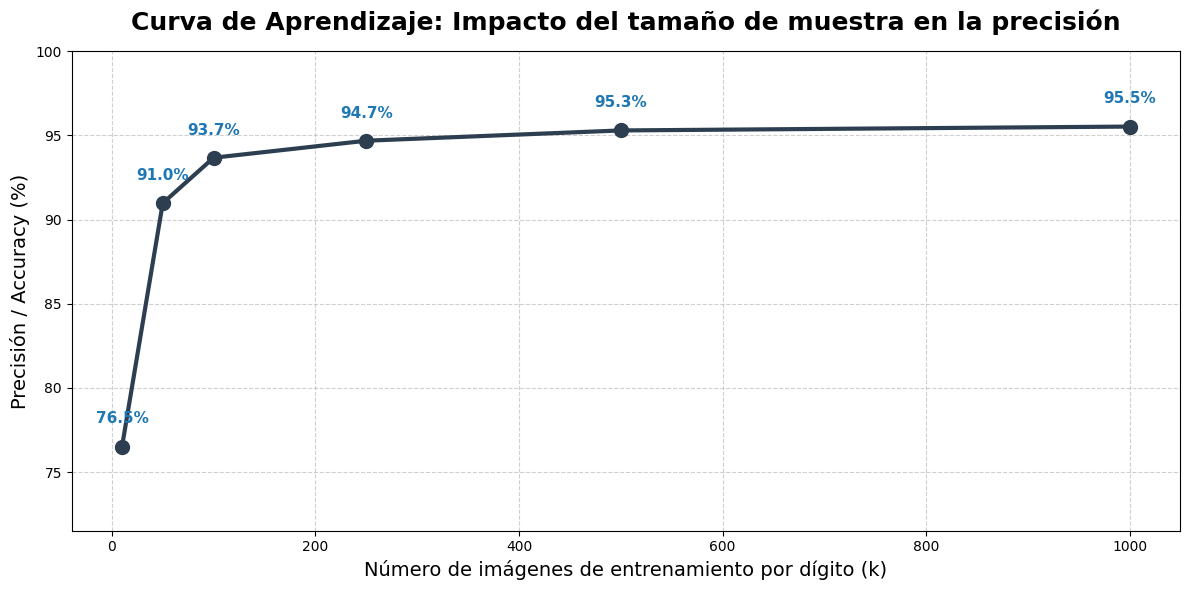

In [107]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Definimos los diferentes tamaños de muestra (k) que queremos probar
valores_k_train = [10, 50, 100, 250, 500, 1000]
precisiones = []

print("--- INICIANDO EXPERIMENTO DE CURVA DE APRENDIZAJE ---")

for k_train in valores_k_train:
    print(f"Construyendo y evaluando modelo con k = {k_train} imágenes por dígito...")
    tiempo_inicio_k = time.time()
    
    # 1. Construir las bases ortonormales para este tamaño de muestra
    bases_temporales = {}
    for d in range(10):
        # Filtramos las imágenes de la clase 'd'
        imagenes_clase_d = X_train_full[y_train_full == d]
        
        # Tomamos solo las primeras 'k_train' imágenes
        muestra_entrenamiento = imagenes_clase_d[:k_train]
        
        # Preprocesamos y aplanamos para formar la matriz temporal M_d
        lista_vectores = []
        for img in muestra_entrenamiento:
            # Recorte
            filas = np.where(img.max(axis=1) > 0)[0]
            cols = np.where(img.max(axis=0) > 0)[0]
            if len(filas) > 0 and len(cols) > 0:
                recorte = img[filas[0]:filas[-1]+1, cols[0]:cols[-1]+1]
            else:
                recorte = img
                
            # Reescalado y normalización
            reescalada = cv2.resize(recorte, (16, 16), interpolation=cv2.INTER_AREA)
            vector = (reescalada / 255.0).flatten()
            lista_vectores.append(vector)
        
        M_d_temp = np.column_stack(lista_vectores)
        
        # Calculamos la SVD para extraer el nuevo "molde"
        U_temp, _, _ = np.linalg.svd(M_d_temp, full_matrices=False)
        bases_temporales[d] = U_temp
        
    # 2. Evaluar el modelo con estas nuevas bases (usando las 10,000 imágenes de prueba)
    aciertos_temp = 0
    for i in range(total_imagenes):
        img_test = X_test_full[i]
        etiq_real = y_test_full[i]
        
        # Usamos nuestra función con k_trunc=21 para aislar el efecto del ruido
        pred = predecir_digito(img_test, bases_temporales, k_trunc=21)
        if pred == etiq_real:
            aciertos_temp += 1
            
    # Calculamos el accuracy y lo guardamos
    acc = (aciertos_temp / total_imagenes) * 100
    precisiones.append(acc)
    tiempo_fin_k = time.time()
    
    print(f" -> Accuracy: {acc:.2f}% (Tiempo: {tiempo_fin_k - tiempo_inicio_k:.2f}s)\n")

# --- 3. GRAFICAR LOS RESULTADOS ---
plt.figure(figsize=(12, 6))
plt.plot(valores_k_train, precisiones, marker='o', color='#2c3e50', linewidth=3, markersize=10)

plt.title('Curva de Aprendizaje: Impacto del tamaño de muestra en la precisión', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Número de imágenes de entrenamiento por dígito (k)', fontsize=14)
plt.ylabel('Precisión / Accuracy (%)', fontsize=14)

# Estética y grilla
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(min(precisiones) - 5, 100)

# Añadir etiquetas de datos directamente sobre los puntos
for x, y in zip(valores_k_train, precisiones):
    plt.text(x, y + 1.2, f'{y:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='tab:blue')
    
plt.tight_layout()
plt.show()

> * Reflexiona sobre el compromiso entre el tamaño del conjunto de entrenamiento (y, por ende,la calidad de la base $B_{d}$) y la precisión de la clasificación.

Los resultados del experimento de sensibilidad, plasmados en la curva de aprendizaje, indican que con una muestra pequeña ( $k_{train} = 10$) la precisión del modelo alcanza un 76.5%. A pesar de la baja muestra, la base ortonormal $B_d$ construida en este punto tan pobre y sesgada como uno esperaría. Para solo tener solo 10 ejemplos, la SVD logra capturar varianza de cómo los humanos dibujan un número; los estilos caligráficos específicos de esas 10 personas logran generalizar lo suficientemente bien como para clasificar correctamente en 7 de cada 10 intentos.

Al pasar de 50 a 250 imágenes, observamos un salto drástico en la precisión, superando rápidamente el 94%. Aquí es donde la SVD brilla. Al aumentar la muestra, la matriz de entrenamiento $M_d$ se enriquece con la variabilidad natural de la escritura. La base $B_d$ resultante abandona los sesgos individuales y logra destilar los "trazos maestros" universales (la señal pura). El subespacio ahora es lo suficientemente robusto para acomodar diferentes inclinaciones y grosores.

A partir de $k_{train} = 500$, la curva se aplana drásticamente. Pasar de 500 a 1000 imágenes solo aporta un 0.23% extra de precisión. Este aplanamiento demuestra que **la complejidad geométrica de un dígito manuscrito es finita**. Una vez que el modelo ha aprendido todas las formas topológicas de hacer un "7" o un "3", inyectarle más imágenes no le aporta nueva información estructural, solo añade redundancia o ruido periférico (valores atípicos de mala escritura).

Adicionalmente, a la luz de esta curva, nuestra configuración metodológica inicial ($k_{train}=1226$ y $k_{trunc}=21$) resulta estratégica al situarse exactamente en la meseta de rendimientos decrecientes de la curva de aprendizaje; con $N=1226$ garantizamos una muestra estadísticamente saturada que captura la variabilidad total del dígito sin el costo computacional de procesar el dataset completo, mientras que el truncamiento en 21 componentes asegura la extracción de la "señal pura" estructural, evitando el overfitting que surgiría al intentar modelar el ruido inherente a muestras tan extensas.

En conclusión, el éxito de este clasificador geométrico (95.67% de precisión) no depende de acumular datos ciegamente, sino de encontrar el equilibrio matemático exacto donde la muestra es lo suficientemente grande para revelar la estructura universal del dígito, y el truncamiento es lo suficientemente estricto para ignorar el ruido humano.

> * Adicionalmente, discute qué ventajas e inconvenientes encuentras en este método de clasificación en comparación con otros enfoques que suelen usarse para clasificar estos dígitos. (aquí no debes implementar otros métodos, pero debes ser riguroso en tu argumentación, explorar las otras opciones existentes)

El método de clasificación por proyecciones en subespacios de bajo rango, fundamentado en la Descomposición en Valores Singulares (SVD), destaca por su balance entre interpretabilidad geométrica y eficiencia. A continuación, se discuten sus ventajas e inconvenientes frente a otros enfoques predominantes en la literatura de reconocimiento de dígitos.

**1. Ventajas del Método de Proyección Ortogonal**

* **Eficiencia en Inferencia:** A diferencia de métodos como *k-Nearest Neighbors* (k-NN), que requieren comparar la imagen de prueba contra cada uno de los ejemplos del conjunto de entrenamiento en tiempo de ejecución —un proceso computacionalmente costoso de orden $O(nd)$—, nuestro método solo requiere 10 productos punto matriciales contra las bases $U_d$. Como señala Hastie et al. (2009), los métodos basados en subespacios reducen drásticamente la latencia en la fase de predicción.
* **Interpretabilidad y Reducción de Ruido:** Al utilizar SVD para construir $B_d$, el modelo realiza una denotación intrínseca. Mientras que clasificadores lineales simples (como la Regresión Logística) pueden verse afectados por el ruido de píxeles individuales, la proyección ortogonal sobre un subespacio truncado garantiza que solo las características estructurales (señal) influyan en la decisión (Trefethen & Bau, 1997).
* **Bajo Costo de Almacenamiento:** Solo necesitamos almacenar las 10 matrices de base $U_d$ (de 256 x 21), en lugar de miles de imágenes de entrenamiento.

**2. Inconvenientes y Limitaciones**

* **Rigidez ante Transformaciones:** Este método es sensible a la alineación. Si un dígito está ligeramente rotado o desplazado fuera del rango capturado por la base $B_d$, la distancia $||q - p_d||$ aumentará. En contraste, las **Redes Neuronales Convolucionales (CNN)** utilizan capas de *pooling* y filtros locales que les otorgan invarianza a la traslación y rotación, permitiéndoles alcanzar precisiones superiores al 99% (LeCun et al., 1998). 
* **Naturaleza Lineal:** El método de subespacios asume que los dígitos de una misma clase habitan en un hiperplano lineal. Sin embargo, la distribución real de los datos suele ser una variedad (manifold) no lineal y compleja. Algoritmos como **Support Vector Machines (SVM)** con núcleos (kernels) no lineales pueden capturar estas fronteras de decisión de manera más efectiva que una proyección ortogonal pura (Schölkopf & Smola, 2002).

**Conclusión Comparativa**

El enfoque de SVD/Proyección es una solución óptima cuando los recursos computacionales son limitados y se requiere una clasificación rápida con alta interpretabilidad. No obstante, para aplicaciones de misión crítica donde la variabilidad posicional es alta, los enfoques de aprendizaje profundo (*Deep Learning*) siguen siendo el estándar de la industria a pesar de su naturaleza de "caja negra" y su alto costo de entrenamiento.

---
**Referencias Bibliográficas**

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning. Springer.
- LeCun, Y., et al. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE.
- Marc Peter Deisenroth, A. Aldo Faisal, y Cheng Soon Ong (2020) Mathematics for Machine Learning. Cambridge University Press.
- Schölkopf, B., & Smola, A. J. (2002). *Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond*. MIT Press.
- Trefethen, L. N., & Bau III, D. (1997). Numerical Linear Algebra. SIAM.

---

## **Ejercicio 3**

Este ejercicio se inspira en pruebas psicotécnicas comunes en procesos de selección laboral y tiene como
objetivo desarrollar soluciones algorítmicas que respondan a preguntas de razonamiento verbal.
Se le solicita que:

### 1.
* Obtenga o elabore una prueba de razonamiento verbal que contenga:
* 10 preguntas de analogía (ej.: ”A es a B como C es a ___”).
* 10 preguntas de contexto (ej.: ”¿Cuál de las siguientes palabras no encaja en el conjunto
{...}?”).

### 2. 
- Desarrolle dos algoritmos (o procedimientos), uno para responder a las preguntas de analogía y
otro para las preguntas de contexto, utilizando un método para convertir frases en representaciones
numéricas (use la libreria SentenceTransformer y también debe usar TF-IDF, la idea es ver si el
rendimiento de los algoritmos depende del embeding usado).

1. **10 Preguntas de Analogía ("A es a B como C es a ___")**

Para estas preguntas, el algoritmo deberá encontrar la relación entre las dos primeras palabras y aplicarla a la tercera para seleccionar la correcta entre un grupo de opciones.

* Frío es a Caliente como Oscuridad es a: (Opciones: Noche, Luz, Sombra, Estrella)

* Médico es a Hospital como Profesor es a: (Opciones: Libro, Escuela, Alumno, Pizarrón)

* Pájaro es a Volar como Pez es a: (Opciones: Nadar, Agua, Escama, Océano)

* Ojo es a Ver como Oído es a: (Opciones: Sonido, Oreja, Escuchar, Sordo)

* Hambre es a Comida como Sed es a: (Opciones: Vaso, Agua, Líquido, Beber)

* Libro es a Leer como Canción es a: (Opciones: Cantar, Escuchar, Música, Radio)

* Árbol es a Bosque como Soldado es a: (Opciones: Guerra, Arma, Ejército, Uniforme)

* Reloj es a Tiempo como Termómetro es a: (Opciones: Clima, Calor, Temperatura, Grados)

* Coche es a Rueda como Perro es a: (Opciones: Animal, Caminar, Gato, Pata)

* Pluma es a Escribir como Cuchillo es a: (Opciones: Cortar, Cocina, Comer, Afilado)

2. **10 Preguntas de Contexto ("¿Cuál no encaja?")**

Para estas preguntas, el algoritmo deberá calcular la distancia entre los vectores de las palabras. La palabra que esté "más lejos" del centro (o promedio) del grupo en el espacio vectorial será la respuesta correcta.

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Manzana, Pera, Plátano, Zanahoria} (Respuesta esperada: Zanahoria - es verdura)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Rojo, Azul, Verde, Círculo} (Respuesta esperada: Círculo - es figura)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Perro, Gato, Caballo, Águila} (Respuesta esperada: Águila - es ave)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Mesa, Silla, Sofá, Ventana} (Respuesta esperada: Ventana - no es mueble)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Coche, Moto, Bicicleta, Barco} (Respuesta esperada: Barco - va por agua)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Feliz, Triste, Enojado, Correr} (Respuesta esperada: Correr - es acción/verbo)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Lunes, Martes, Enero, Jueves} (Respuesta esperada: Enero - es mes)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Piano, Guitarra, Tambor, Pintura} (Respuesta esperada: Pintura - no es instrumento)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Ojo, Nariz, Oreja, Zapato} (Respuesta esperada: Zapato - es prenda)

* ¿Cuál de las siguientes palabras no encaja en el conjunto? {Agua, Leche, Jugo, Pan} (Respuesta esperada: Pan - es sólido)

In [9]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
import logging
from transformers import logging as transformers_logging
# Silencia los avisos de carga de modelos
# transformers_logging.set_verbosity_error()
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ---------------------------------------------------------
# 1. INICIALIZACIÓN DE LOS MODELOS (Nuestros creadores de vectores)
# ---------------------------------------------------------

# TF-IDF: Crea representaciones basadas en la frecuencia de las palabras.
vectorizador_tfidf = TfidfVectorizer()

# SentenceTransformer: Usamos un modelo multilingüe para que entienda español.
# Esto descargará un modelo pre-entrenado la primera vez que lo corras.
modelo_transformer = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# ---------------------------------------------------------
# 2. ALGORITMO PARA ANALOGÍAS
# ---------------------------------------------------------
def resolver_analogia(a, b, c, opciones, modelo_tipo, vocabulario_total=None):
    """
    Resuelve analogías del tipo: A es a B como C es a ___.
    """
    # Función auxiliar para obtener el vector dependiendo del modelo
    def obtener_vector(palabra):
        if modelo_tipo == 'tfidf':
            # TF-IDF requiere transformar una lista, obtenemos un array denso de 1D
            return vectorizador_tfidf.transform([palabra]).toarray()[0]
        else:
            # SentenceTransformer devuelve directamente el vector denso
            return modelo_transformer.encode(palabra)

    # Obtenemos los vectores de las 3 palabras de la premisa
    vec_a = obtener_vector(a)
    vec_b = obtener_vector(b)
    vec_c = obtener_vector(c)
    
    # Aplicamos la combinación lineal: D = B - A + C
    vec_objetivo = vec_b - vec_a + vec_c
    
    # Evaluamos las opciones
    mejor_opcion = None
    mayor_similitud = -1 # El coseno va de -1 a 1, inicializamos en el más bajo
    
    for opcion in opciones:
        vec_opcion = obtener_vector(opcion)
        # cosine_similarity espera matrices 2D, así que usamos reshape(1, -1)
        similitud = cosine_similarity(vec_objetivo.reshape(1, -1), vec_opcion.reshape(1, -1))[0][0]
        
        if similitud > mayor_similitud:
            mayor_similitud = similitud
            mejor_opcion = opcion
            
    return mejor_opcion, mayor_similitud

# ---------------------------------------------------------
# 3. ALGORITMO PARA CONTEXTO (El intruso)
# ---------------------------------------------------------
def resolver_contexto(conjunto_palabras, modelo_tipo):
    """
    Encuentra la palabra que no encaja en un conjunto.
    """
    # Función auxiliar para obtener la matriz de vectores
    if modelo_tipo == 'tfidf':
        # Obtenemos la matriz de todos los vectores del conjunto
        matriz_vectores = vectorizador_tfidf.transform(conjunto_palabras).toarray()
    else:
        matriz_vectores = modelo_transformer.encode(conjunto_palabras)
        
    # Calculamos el "centroide" o promedio de todos los vectores (axis=0 promedia las columnas)
    centroide = np.mean(matriz_vectores, axis=0)
    
    intruso = None
    menor_similitud = 2 # Inicializamos por encima del máximo posible (1)
    
    # Buscamos la palabra cuyo vector sea MENOS similar al centroide
    for i, palabra in enumerate(conjunto_palabras):
        vec_palabra = matriz_vectores[i]
        similitud = cosine_similarity(centroide.reshape(1, -1), vec_palabra.reshape(1, -1))[0][0]
        
        if similitud < menor_similitud:
            menor_similitud = similitud
            intruso = palabra
            
    return intruso, menor_similitud

# ---------------------------------------------------------
# 4. PREPARACIÓN Y PRUEBA (Ejemplo con 1 pregunta de cada una)
# ---------------------------------------------------------

# Para TF-IDF, necesitamos "ajustar" (fit) el vocabulario primero con todas las palabras que usaremos.
vocabulario_prueba = ["Frío", "Caliente", "Oscuridad", "Noche", "Luz", "Sombra", "Estrella",
                      "Manzana", "Pera", "Plátano", "Zanahoria"]
vectorizador_tfidf.fit(vocabulario_prueba)

print("--- PRUEBA DE ANALOGÍA ---")
opciones_ana = ["Noche", "Luz", "Sombra", "Estrella"]
# Esperamos "Luz"
res_tfidf_ana = resolver_analogia("Frío", "Caliente", "Oscuridad", opciones_ana, 'tfidf')
res_trans_ana = resolver_analogia("Frío", "Caliente", "Oscuridad", opciones_ana, 'transformer')

print(f"Resultado TF-IDF: {res_tfidf_ana[0]} (Similitud: {res_tfidf_ana[1]:.4f})")
print(f"Resultado Transformer: {res_trans_ana[0]} (Similitud: {res_trans_ana[1]:.4f})")

print("\n--- PRUEBA DE CONTEXTO ---")
conjunto_ctx = ["Manzana", "Pera", "Plátano", "Zanahoria"]
# Esperamos "Zanahoria"
res_tfidf_ctx = resolver_contexto(conjunto_ctx, 'tfidf')
res_trans_ctx = resolver_contexto(conjunto_ctx, 'transformer')

print(f"Resultado TF-IDF: {res_tfidf_ctx[0]} (Similitud al centroide: {res_tfidf_ctx[1]:.4f})")
print(f"Resultado Transformer: {res_trans_ctx[0]} (Similitud al centroide: {res_trans_ctx[1]:.4f})")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 547.47it/s, Materializing param=pooler.dense.weight]                               


--- PRUEBA DE ANALOGÍA ---
Resultado TF-IDF: Noche (Similitud: 0.0000)
Resultado Transformer: Luz (Similitud: 0.6353)

--- PRUEBA DE CONTEXTO ---
Resultado TF-IDF: Manzana (Similitud al centroide: 0.5000)
Resultado Transformer: Pera (Similitud al centroide: 0.7854)


### 3
* Genere representaciones gráficas que ilustren las relaciones entre las frases de la prueba.


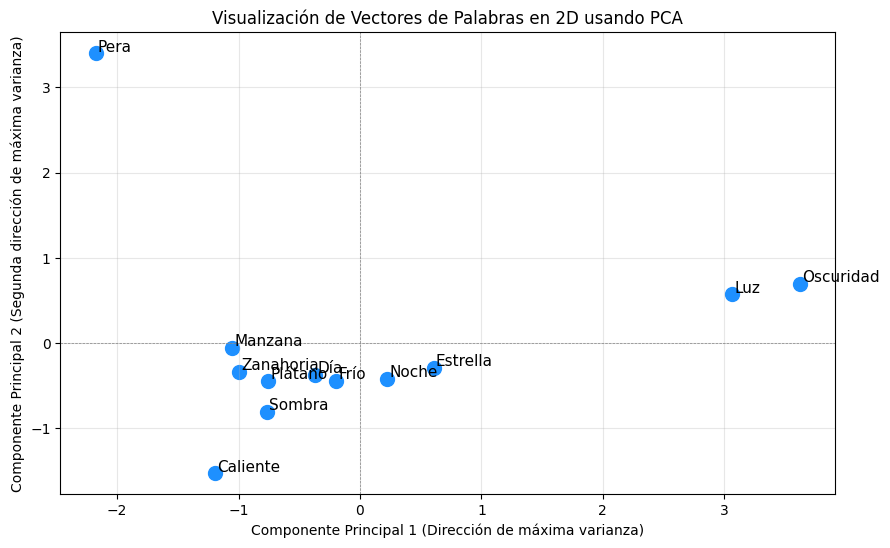

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Definimos las palabras que queremos graficar
palabras = ["Día", "Frío", "Caliente", "Oscuridad", "Luz", "Noche", "Sombra", "Estrella", 
            "Manzana", "Pera", "Plátano", "Zanahoria"]

# 2. Obtenemos los vectores matemáticos usando el Transformer (que es el que tiene significado semántico)
vectores = modelo_transformer.encode(palabras)

# 3. Aplicamos PCA
# Inicializamos PCA pidiéndole específicamente que reduzca el espacio a 2 componentes (2D)
pca = PCA(n_components=2)

# La función fit_transform hace dos cosas: 
# a) Calcula la matriz de covarianza y sus vectores propios (fit)
# b) Proyecta los vectores de 384 dimensiones a esas 2 nuevas dimensiones (transform)
vectores_2d = pca.fit_transform(vectores)

# 4. Generamos el gráfico de dispersión (Scatter plot)
plt.figure(figsize=(10, 6)) # Tamaño de la figura
# Graficamos todas las filas (:) de la columna 0 (eje X) y la columna 1 (eje Y)
plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1], color='dodgerblue', s=100) # s es el tamaño de los puntos

# 5. Añadimos el texto a cada punto para saber qué palabra es
for i, palabra in enumerate(palabras):
    # Sumamos un pequeño valor (0.02) a X y Y para que el texto no quede encima del punto
    plt.annotate(palabra, (vectores_2d[i, 0] + 0.02, vectores_2d[i, 1] + 0.02), fontsize=11)

# Configuraciones estéticas del gráfico
plt.title("Visualización de Vectores de Palabras en 2D usando PCA")
plt.xlabel("Componente Principal 1 (Dirección de máxima varianza)")
plt.ylabel("Componente Principal 2 (Segunda dirección de máxima varianza)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5) # Línea central horizontal
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5) # Línea central vertical
plt.grid(True, alpha=0.3)
plt.show()

### 4.
* Evalúe el rendimiento de sus algoritmos y compare los resultados obtenidos.


### Nota: 
*La obtención de las preguntas (analogías y contexto) es parte del desafío; puede buscarlas en fuentes disponibles en Internet.